In [7]:
import pandas as pd
tech_results = pd.read_csv("tech_with_combi_1.csv").drop(columns=["Unnamed: 0","date"])
healthcare_results = pd.read_csv("healthcare_with_combi_1.csv").drop(columns=["Unnamed: 0","date"])
healthcare_results

,rolling_alpha_5f,lasso,ridge,xgboost,lgbm,rf,pca,lstm,benchmark_alpha,simple_avg,err_weighted
0,-0.492296,0.174751,0.176814,0.027119,0.022587,0.042087,0.170171,0.095191,0.00000,0.101246,0.101246
1,-0.221179,0.082346,0.081157,0.027123,0.022587,0.019916,0.077714,-0.005149,0.00000,0.043671,0.035388
2,-0.214097,0.052267,0.050763,0.029551,0.022587,0.024562,0.050389,0.001391,0.00000,0.033073,0.030428
3,-0.196113,0.018615,0.013510,0.018520,0.018816,0.026010,0.009793,-0.002831,0.00000,0.014633,0.013905
4,-0.155538,-0.043474,-0.048267,-0.059702,-0.068611,-0.032137,-0.023693,-0.123004,0.00000,-0.056984,-0.096835
...,...,...,...,...,...,...,...,...,...,...,...
53621,0.027648,0.014150,0.014323,0.037521,0.035474,0.036374,0.012546,0.002151,0.00354,0.021791,0.029175
53622,0.027850,0.014026,0.014132,0.037521,0.035474,0.038279,0.012357,0.002268,0.00354,0.022008,0.029337
53623,0.027936,0.014258,0.014428,0.037521,0.035474,0.037728,0.012663,0.002181,0.00354,0.022036,0.029471
53624,0.028354,0.014568,0.014763,0.037521,0.035474,0.037304,0.012975,0.001821,0.00354,0.022061,0.030166


In [8]:
import numpy as np
import pandas as pd
from scipy.stats import t
from typing import List, Sequence, Callable, Tuple
from itertools import islice

class InvalidParameterException(Exception):
    """Exception raised for invalid input parameters."""
    def __init__(self, message: str):
        super().__init__(message)

class ZeroVarianceException(ArithmeticError):
    """Exception raised when variance in DM test is zero."""
    def __init__(self, message: str):
        super().__init__(message)

def autocovariance(X: Sequence[float], k: int, mean: float) -> float:
    """Returns the k-lagged autocovariance for the input iterable."""
    return sum((a - mean) * (b - mean) for a, b in zip(islice(X, k, None), X)) / len(X)

def evaluate_pvalue(pvalue: float) -> int:
    """
    Evaluates the p-value to determine model equivalence.
    - Returns 1 if p-value >= 0.05 (statistically similar, fail to reject H0)
    - Returns -1 if p-value < 0.05 (statistically different, reject H0)
    """
    return 1 if pvalue >= 0.05 else -1

def dm_test(
    V: Sequence[float],
    P1: Sequence[float],
    P2: Sequence[float],
    *,
    loss: Callable[[float, float], float] = lambda u, v: (u - v) ** 2,
    h: int = 1,
    one_sided: bool = False,
    harvey_correction: bool = True
) -> Tuple[float, float]:
    """
    Performs the Diebold-Mariano (DM) test for predictive accuracy comparison.

    Parameters:
    - V: True observed values
    - P1: Forecasts from model 1
    - P2: Forecasts from model 2
    - loss: Loss function (default is squared error loss)
    - h: Forecast horizon (default: 1)
    - one_sided: Whether to use a one-sided test (default: False)
    - harvey_correction: Whether to apply Harvey adjustment (default: True)

    Returns:
    - DM test statistic
    - p-value
    """
    d = np.array([loss(V[i], P1[i]) - loss(V[i], P2[i]) for i in range(len(V))])
    mean_d = np.mean(d)

    # Compute HAC variance estimate
    gamma = np.array([np.cov(d[:-i], d[i:])[0, 1] if i > 0 else np.var(d, ddof=1) for i in range(h)])
    var_d = (gamma[0] + 2 * np.sum(gamma[1:])) / len(d)

    if var_d == 0:
        raise ZeroVarianceException("Variance of the DM statistic is zero. The prediction series might be identical.")

    dm_stat = mean_d / np.sqrt(var_d)

    # Apply Harvey correction if required
    n = len(d)
    if harvey_correction:
        harvey_adj = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
        dm_stat *= harvey_adj

    # Compute p-value
    p_value = 2 * (1 - t.cdf(abs(dm_stat), df=n-1)) if not one_sided else (1 - t.cdf(dm_stat, df=n-1))

    return dm_stat, p_value

def generate_dm_test_matrix(results_df: pd.DataFrame, outcome_var: str, forecast_vars: List[str]
                             ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Generates a pairwise DM test statistic and p-value matrix from a results DataFrame.

    Parameters:
    - results_df: DataFrame containing the true values and forecasts
    - outcome_var: Column name of the observed outcome variable
    - forecast_vars: List of column names corresponding to forecasts

    Returns:
    - DataFrame of DM test statistics
    - DataFrame of p-values
    """
    n = len(forecast_vars)
    dm_stat_matrix = np.zeros((n, n))
    pvalue_matrix = np.zeros((n, n))

    for i, f1 in enumerate(forecast_vars):
        for j, f2 in enumerate(forecast_vars):
            if i == j:
                dm_stat_matrix[i, j] = 0
                pvalue_matrix[i, j] = 0
            elif i < j:  # Compute only for upper triangle and mirror values
                try:
                    common_index = results_df[outcome_var].dropna().index
                    V = results_df.loc[common_index, outcome_var].values
                    P1 = results_df.loc[common_index, f1].values
                    P2 = results_df.loc[common_index, f2].values

                    dmstat, pvalue = dm_test(V, P1, P2, one_sided=True)

                    dm_stat_matrix[i, j] = dmstat
                    pvalue_matrix[i, j] = evaluate_pvalue(pvalue)
                    dm_stat_matrix[j, i] = -dmstat  # Maintain symmetry
                    pvalue_matrix[j, i] = evaluate_pvalue(pvalue)  # Ensure p-value symmetry

                except Exception as e:
                    dm_stat_matrix[i, j] = np.nan
                    pvalue_matrix[i, j] = np.nan
                    dm_stat_matrix[j, i] = np.nan
                    pvalue_matrix[j, i] = np.nan

    # Convert matrices to DataFrame format
    dm_stat_df = pd.DataFrame(dm_stat_matrix, index=forecast_vars, columns=forecast_vars)
    pvalue_df = pd.DataFrame(pvalue_matrix, index=forecast_vars, columns=forecast_vars)

    return dm_stat_df, pvalue_df

Transformations to make DM Matrix

In [9]:
def transform_matrix(df):
    transformed_df = df.copy().astype(str)
    for row in df.index:
        for col in df.columns:
            if df.loc[row, col] < 0:
                transformed_df.loc[row, col] = "row"  # Row model is better
            elif df.loc[row, col] > 0:
                transformed_df.loc[row, col] = "col"  # Column model is better
            else:
                transformed_df.loc[row, col] = "same"  # Same model
    return transformed_df

def apply_equivalent(dm_transformed, reference_df):
    dm_transformed_updated = dm_transformed.copy()
    for row in dm_transformed.index:
        for col in dm_transformed.columns:
            if reference_df.loc[row, col] == -1:
                continue
            elif reference_df.loc[row, col] > 0:
                dm_transformed_updated.loc[row, col] = "equivalent"  # Column model is better
            else:
                continue  # Same model
    return dm_transformed_updated

def overall_transformation(dm_stat_df, dm_pvalue_df):
    dm_transformed = transform_matrix(dm_stat_df)
    dm_transformed_updated = apply_equivalent(dm_transformed, dm_pvalue_df)
    return dm_transformed_updated

Plotting Function

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

def heat_map_plotter(df):
    mapping = {"row": -1, "same": 0, "equivalent": 1, "col": 2}  # Ensure "equivalent" and "same" are treated the same

    # Convert categorical values to numerical for visualization
    dm_numeric = df.replace(mapping)

    # Define renaming mapping
    rename_mapping = {
        "lstm": "LSTM",
        "ridge": "Ridge",
        "lasso": "Lasso",
        "lgbm": "LightGBM",
        "xgboost": "XGBoost",
        "err_weighted": "BG",
        "simple_avg": "SA",
        "pca": "PCR",
        "rf": "RF",
        "benchmark_alpha": "Benchmark"
    }

    # Rename index and columns (if needed)
    dm_numeric_renamed = dm_numeric.rename(index=rename_mapping, columns=rename_mapping)

    # Define color mapping
    cmap = ListedColormap(["lightseagreen", "#000000", "crimson", "navy"])  
    # Red = "row", Black = "same/equivalent", White = unused, Blue = "col"

    bounds = [-1.5, -0.5, 0.5, 1.5, 2.5]  # Ensure distinct bins for each category
    norm = BoundaryNorm(bounds, cmap.N)

    # Create a mask for the upper triangle
    mask = np.triu(np.ones_like(dm_numeric_renamed, dtype=bool),k=1)

    # Set the upper triangle to NaN
    dm_numeric_masked = dm_numeric_renamed.mask(mask)

    # Create a figure
    plt.figure(figsize=(10, 8))

    # Draw heatmap without borders
    ax = sns.heatmap(
        dm_numeric_masked,
        cmap=cmap,
        norm=norm,
        mask=mask,
        cbar=False,
        linewidths=0,  # Remove default grid lines
        linecolor="black"  # Will be used selectively
    )

    # Manually add black outlines only to colored squares
    for i in range(dm_numeric_masked.shape[0]):
        for j in range(dm_numeric_masked.shape[1]):
            value = dm_numeric_masked.iloc[i, j]
            if value in [-1, 1]:  # -1 (row model better), 2 (col model better)
                rect = plt.Rectangle(
                    (j, i), 1, 1, fill=False, edgecolor="black", linewidth=1
                )
                ax.add_patch(rect)

    # Add a legend manually
    legend_patches = [
        mpatches.Patch(color="lightseagreen", label="Model 1 Better"),
        mpatches.Patch(color="crimson", label="Forecast Equivalence"),
        mpatches.Patch(color="navy", label="Model 2 Better"),
        mpatches.Patch(color="#000000", label="NA")
    ]

    plt.xlabel("Model 2", fontsize=14, fontweight = "bold")
    plt.ylabel("Model 1", fontsize=14, fontweight = "bold")

    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(handles=legend_patches, loc="upper right", title="Categories", frameon=True,
            title_fontsize = 14, fontsize = 12, bbox_to_anchor=(0.9, 0.9))
    plt.show()


In [27]:
# DM Test for all outcomes
outcome_var = 'rolling_alpha_5f'
forecast_vars = ['lstm', 'ridge', 'rf', 'lgbm', 'xgboost', 'benchmark_alpha', 'err_weighted', 'simple_avg', 'lasso', 'pca']

dm_stat_df_healthcare, dm_pvalue_df_healthcare = generate_dm_test_matrix(healthcare_results, outcome_var, forecast_vars)
dm_stat_df_tech, dm_pvalue_df_tech = generate_dm_test_matrix(tech_results, outcome_var, forecast_vars)

dm_transformed_healthcare = overall_transformation(dm_stat_df_healthcare,dm_pvalue_df_healthcare)
dm_transformed_tech = overall_transformation(dm_stat_df_tech,dm_pvalue_df_tech)

In [32]:
dm_stat_df_healthcare

,lstm,ridge,rf,lgbm,xgboost,benchmark_alpha,err_weighted,simple_avg,lasso,pca
lstm,0.000000,-1.668923,0.659532,1.084058,-1.287194,-11.040045,4.535005,0.379609,-1.643448,-2.317938
ridge,1.668923,0.000000,2.917908,2.119137,1.592964,-2.326396,6.998498,3.779623,-0.273276,-3.159048
rf,-0.659532,-2.917908,0.000000,-0.069675,-5.013341,-6.871610,9.428800,-0.391701,-2.847036,-4.052391
lgbm,-1.084058,-2.119137,0.069675,0.000000,-2.938868,-10.053409,4.868137,-0.137501,-2.082649,-2.881194
xgboost,1.287194,-1.592964,5.013341,2.938868,0.000000,-5.956908,10.376526,2.767449,-1.560895,-2.447155
benchmark_alpha,11.040045,2.326396,6.871610,10.053409,5.956908,0.000000,8.568407,5.844446,2.286905,2.199891
err_weighted,-4.535005,-6.998498,-9.428800,-4.868137,-10.376526,-8.568407,0.000000,-20.630906,-6.773998,-9.275328
simple_avg,-0.379609,-3.779623,0.391701,0.137501,-2.767449,-5.844446,20.630906,0.000000,-3.648183,-5.690935
lasso,1.643448,0.273276,2.847036,2.082649,1.560895,-2.286905,6.773998,3.648183,0.000000,-2.786611
pca,2.317938,3.159048,4.052391,2.881194,2.447155,-2.199891,9.275328,5.690935,2.786611,0.000000


In [28]:
# dm_stat_df

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

def heat_map_plotter(df, setyticks=True, xtitle=True, ytitle=True):
    mapping = {"row": -1, "same": 0, "equivalent": 1, "col": 2}
    dm_numeric = df.replace(mapping)

    rename_mapping = {
        "lstm": "LSTM", "ridge": "Ridge", "lasso": "Lasso", "lgbm": "LightGBM", 
        "xgboost": "XGBoost", "err_weighted": "BG", "simple_avg": "SA", 
        "pca": "PCR", "rf": "RF", "benchmark_alpha": "Benchmark"
    }
    dm_numeric_renamed = dm_numeric.rename(index=rename_mapping, columns=rename_mapping)
    
    cmap = ListedColormap(["lightseagreen", "#000000", "lightpink", "navy"])
    bounds = [-1.5, -0.5, 0.5, 1.5, 2.5]
    norm = BoundaryNorm(bounds, cmap.N)
    
    mask = np.triu(np.ones_like(dm_numeric_renamed, dtype=bool), k=1)
    dm_numeric_masked = dm_numeric_renamed.mask(mask)
    
    fig, ax = plt.subplots(figsize=(16, 12))
    sns.heatmap(
        dm_numeric_masked, cmap=cmap, norm=norm, mask=mask, cbar=False,
        linewidths=0, linecolor="black", ax=ax
    )
    
    for i in range(dm_numeric_masked.shape[0]):
        for j in range(dm_numeric_masked.shape[1]):
            value = dm_numeric_masked.iloc[i, j]
            if value in [-1, 1]:  
                rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="black", linewidth=1)
                ax.add_patch(rect)
    
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha="right", fontsize=15 if setyticks else 0)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=15)
    
    if not setyticks:
        ax.set_yticks([])
    if xtitle:
        ax.set_xlabel("Model 2", fontsize=12, fontweight="bold")
    if ytitle:
        ax.set_ylabel("Model 1", fontsize=12, fontweight="bold")
    legend_patches = [
        mpatches.Patch(color="lightseagreen", label="Model 1 Better"),
        mpatches.Patch(color="lightpink", label="Forecast Equivalence"),
        mpatches.Patch(color="navy", label="Model 2 Better"),
        mpatches.Patch(color="#000000", label="NA")
    ]
    plt.legend(handles=legend_patches, loc="lower center", title="Categories", 
            title_fontsize=20, fontsize=16, frameon=True, ncol=4, bbox_to_anchor=(0.5, -0.05))
    
    plt.show()

# heat_map_plotter(dm_transformed_healthcare)
# heat_map_plotter(dm_transformed_tech)

# Adjust layout
# plt.tight_layout()

# # Add a single legend outside the plot


# plt.show()

In [33]:
import pandas as pd
import numpy as np
from scipy.stats import chi2
from itertools import combinations

def calculate_proportions(df, significance_level=0.05):
    # Model name mapping
    rename_mapping = {
        "lstm": "LSTM",
        "ridge": "Ridge",
        "lasso": "Lasso",
        "lgbm": "LightGBM",
        "xgboost": "XGBoost",
        "err_weighted": "BG",
        "simple_avg": "SA",
        "pca": "PCR",
        "rf": "RF",
        "benchmark_alpha": "Benchmark"
    }
    
    # Prepare the data - select only columns we need
    prediction_columns = list(rename_mapping.keys())
    df_long = (
        df[['rolling_alpha_5f'] + prediction_columns]
        .copy()
        .reset_index(drop=True)
        .assign(time=lambda x: x.index + 1)
        .melt(id_vars=['time', 'rolling_alpha_5f'], 
              var_name='model', 
              value_name='pred')
    )
    
    # Apply model name mapping
    df_long['model'] = df_long['model'].map(rename_mapping)
    
    # Process predictions and calculate absolute errors
    df_long['pred'] = df_long['pred'].clip(lower=0)
    df_long['err'] = (df_long['pred'] - df_long['rolling_alpha_5f']).abs()
    
    # Get unique model names and all possible pairs
    model_names = sorted(df_long['model'].unique())
    model_pairs = list(combinations(model_names, 2))
    
    # Initialize results
    final_df = pd.DataFrame(columns=["Model 1", "Model 2", "Outcome"])
    better_count = {model: 0 for model in model_names}
    total_comparisons = {model: 0 for model in model_names}
    
    def compute_wald_one_sided(errors1, errors2):
        diff = errors1 - errors2
        mean_diff = np.mean(diff)
        var_diff = np.var(diff, ddof=1) / len(diff)
        wald_stat = (mean_diff ** 2) / var_diff
        return wald_stat
    
    # Compare all model pairs
    for model1, model2 in model_pairs:
        model1_err = df_long[df_long['model'] == model1]['err'].values
        model2_err = df_long[df_long['model'] == model2]['err'].values
        
        wald_stat = compute_wald_one_sided(model1_err, model2_err)
        critical_value = chi2.ppf(1 - significance_level, df=1)
        
        if wald_stat > critical_value:
            if np.mean(model1_err) < np.mean(model2_err):
                better_count[model1] += 1
                outcome = "Model 1"
                print(f"{model1} is better than {model2}")
            else:
                better_count[model2] += 1
                outcome = "Model 2"
                print(f"{model1} is worse than {model2}")
        else:
            outcome = "Equivalent"
            print(f"Both {model1} and {model2} are equivalent")
        
        # Add to results dataframe
        final_df = pd.concat([
            final_df,
            pd.DataFrame({
                "Model 1": [model1],
                "Model 2": [model2],
                "Outcome": [outcome]
            })
        ], ignore_index=True)
        
        total_comparisons[model1] += 1
        total_comparisons[model2] += 1
    
    # Calculate proportions
    proportion_better = {
        model: better_count[model] / total_comparisons[model] 
        for model in model_names
    }
    
    return final_df, proportion_better


In [105]:
comparison_results_healthcare, proportions_healthcare = calculate_proportions(healthcare_results)
comparison_results_tech, proportions_tech = calculate_proportions(tech_results)
# print(comparison_results)
# print(proportions)

BG is better than Benchmark
BG is better than LSTM
BG is better than Lasso
BG is better than LightGBM
BG is better than PCR
BG is better than RF
BG is better than Ridge
BG is better than SA
BG is better than XGBoost
Benchmark is worse than LSTM
Benchmark is worse than Lasso
Benchmark is worse than LightGBM
Benchmark is worse than PCR
Benchmark is worse than RF
Benchmark is worse than Ridge
Benchmark is worse than SA
Benchmark is worse than XGBoost
LSTM is worse than Lasso
LSTM is worse than LightGBM
LSTM is better than PCR
LSTM is worse than RF
LSTM is worse than Ridge
LSTM is worse than SA
LSTM is worse than XGBoost
Lasso is worse than LightGBM
Lasso is better than PCR
Lasso is worse than RF
Lasso is better than Ridge
Lasso is worse than SA
Lasso is worse than XGBoost
LightGBM is better than PCR
Both LightGBM and RF are equivalent
LightGBM is better than Ridge
LightGBM is better than SA
LightGBM is worse than XGBoost
PCR is worse than RF
PCR is worse than Ridge
PCR is worse than SA
PC

In [74]:
# comparison_results_healthcare

C:\Users\wjlwi\AppData\Local\Temp\ipykernel_36924\1633089845.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


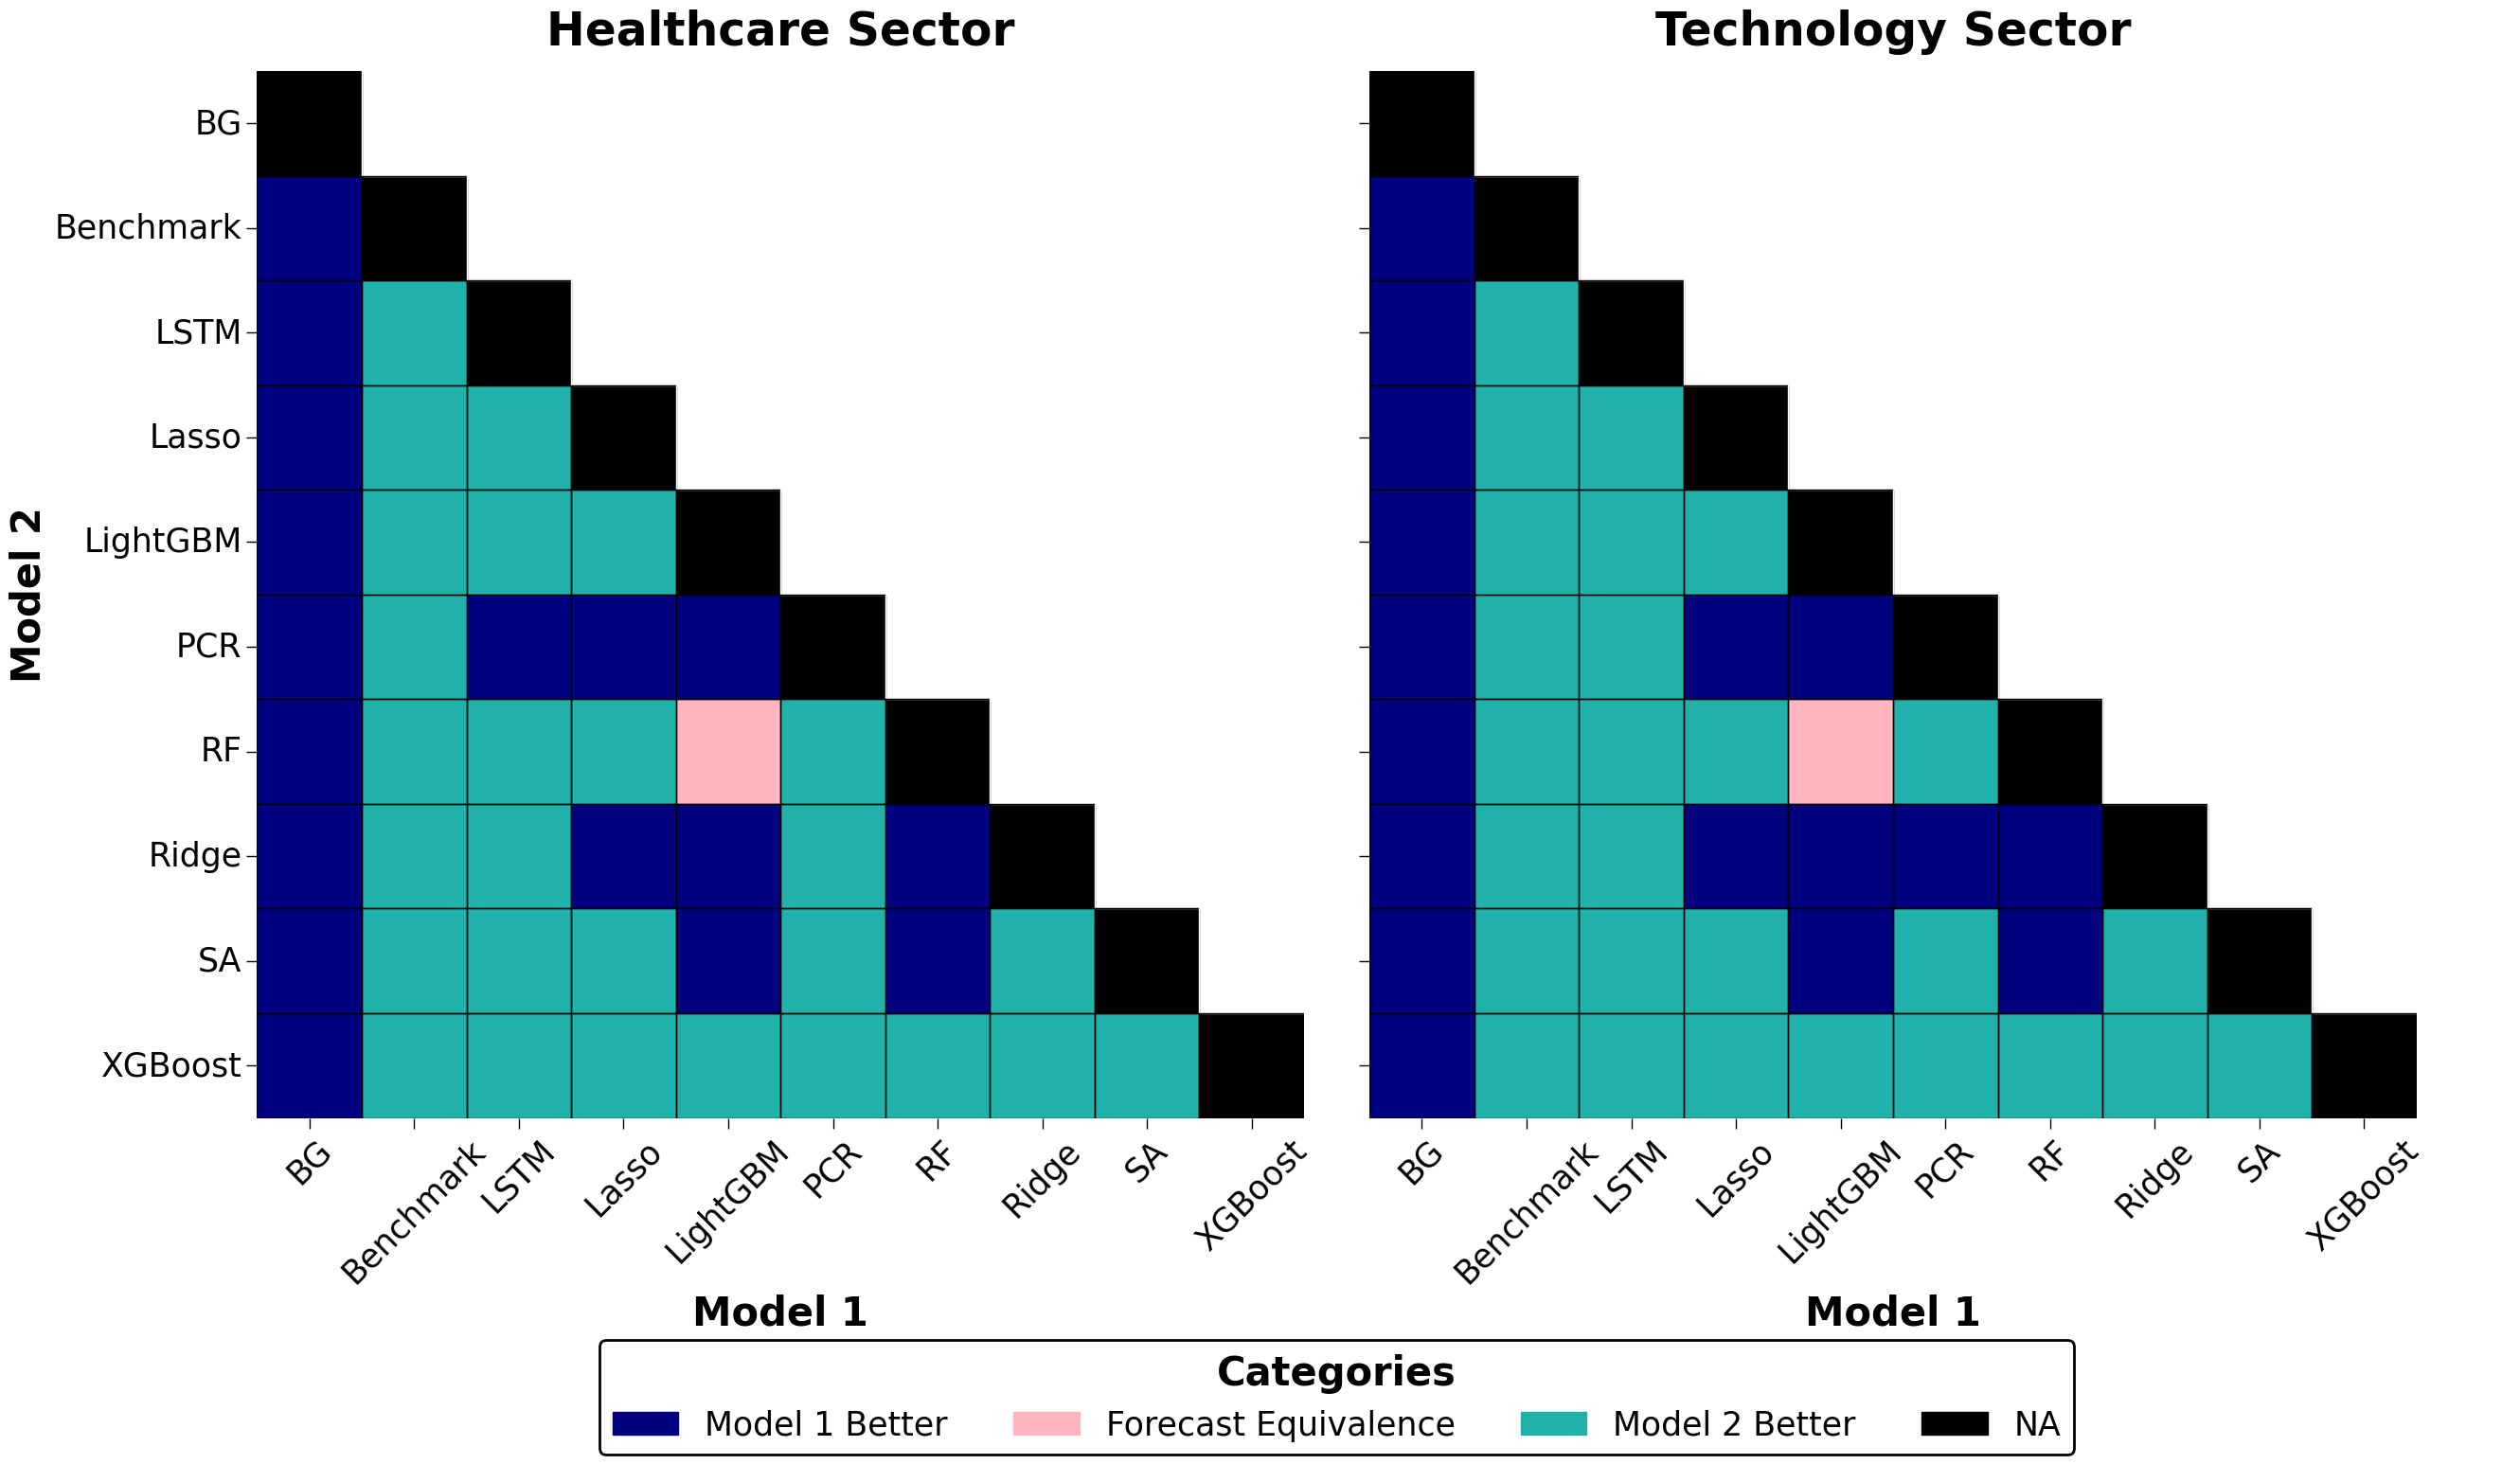

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

def plot_side_by_side_heatmaps(healthcare_df, tech_df):
    # Create figure with 2 subplots and space for legend below
    fig = plt.figure(figsize=(32, 14))
    gs = fig.add_gridspec(2, 2, height_ratios=[12, 1], width_ratios=[1, 1], hspace=-0.2, wspace=-0.1)
    
    ax1 = fig.add_subplot(gs[0, 0])  # Healthcare heatmap (left)
    ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)  # Tech heatmap (shares y-axis)
    legend_ax = fig.add_subplot(gs[1, :])  # Common legend area
    
    # Plot both heatmaps
    plot_single_heatmap(healthcare_df, ax1, "Healthcare Sector", show_yticks=True)
    plot_single_heatmap(tech_df, ax2, "Technology Sector", show_yticks=False)
    
    # Create common legend
    legend_patches = [
        mpatches.Patch(color="navy", label="Model 1 Better"),
        mpatches.Patch(color="lightpink", label="Forecast Equivalence"),
        mpatches.Patch(color="lightseagreen", label="Model 2 Better"),
        mpatches.Patch(color="#000000", label="NA")
    ]
    
    legend =legend_ax.legend(
        handles=legend_patches,
        loc='center',
        bbox_to_anchor=(0.5, -3.5),
        ncol=4,
        fontsize=25,
        title="Categories",
        title_fontsize=30,
        frameon = True,
        edgecolor='black',
        framealpha=1
    )
    legend.get_frame().set_linewidth(2)
    legend.get_title().set_fontweight('bold')
    # Hide the legend axis
    legend_ax.axis('off')
    legend.set_visible(True)
    plt.tight_layout()
    plt.show()

def plot_single_heatmap(df, ax, title, show_yticks=True):
    outcome_mapping = {
        "Model 1": -1,    # lightseagreen
        "Equivalent": 0,  # lightpink
        "Model 2": 1      # navy
    }
    
    models = sorted(set(df['Model 1'].unique()).union(set(df['Model 2'].unique())))
    comparison_matrix = pd.DataFrame(-2, index=models, columns=models, dtype=int)
    
    for _, row in df.iterrows():
        model1 = row['Model 1']
        model2 = row['Model 2']
        outcome = row['Outcome']
        comparison_matrix.loc[model2, model1] = outcome_mapping[outcome]
    
    mask = np.triu(np.ones_like(comparison_matrix, dtype=bool), k=1)
    cmap = ListedColormap(["navy", "lightpink", "lightseagreen", "#000000"])
    bounds = [-1.5, -0.5, 0.5, 1.5, 2.5]
    norm = BoundaryNorm(bounds, cmap.N)
    np.fill_diagonal(comparison_matrix.values, 2)
    
    sns.heatmap(
        comparison_matrix, 
        cmap=cmap, 
        norm=norm, 
        mask=mask, 
        cbar=False,
        linewidths=0.5, 
        linecolor="black", 
        ax=ax,
        square=True
    )
    
    ax.set_title(title, pad=20, fontsize = 35, fontweight = 'bold')
    ax.tick_params(
        axis='both',          # Both x and y axes
        which='both',         # Both major and minor ticks
        length=8,            # Tick length in points (default is 4)
        width=1,             # Tick width in points
        colors='black'       # Tick color
    )
    for i in range(comparison_matrix.shape[0]):
        for j in range(comparison_matrix.shape[1]):
            if i >= j:
                rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="black", linewidth=1)
                ax.add_patch(rect)
            else:
                rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="white", linewidth=1)
                ax.add_patch(rect)
    
    # Y-axis handling
    if show_yticks:
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha="right", fontsize=25)
        ax.set_ylabel("Model 2", fontsize=30, fontweight="bold")
    else:
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.set_ylabel("")
    
    # X-axis (same for both)
    ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, fontsize=25)
    ax.set_xlabel("Model 1", fontsize=30, fontweight="bold")

# Usage
plot_side_by_side_heatmaps(comparison_results_healthcare, comparison_results_tech)